In [1]:
import jax
import jax.numpy as jnp, jax.random as jr
from msvgd import MSVGD
import matplotlib.pyplot as plt

# Bivariate Gaussian

In [2]:
def gaussian_logdensity(x):
    """
    Log-density of the 2D Gaussian distribution.
    x : shape (2,) — as expected by MSVGD's logdensity argument
    returns : shape (1,)
    """
    return -x**2/2

In [3]:
gaussian_solver = MSVGD(gaussian_logdensity)
x0 = jr.normal(jr.PRNGKey(1), shape=(200, 2))
_ = gaussian_solver.solve(x0, mitosis_splits=3, optimizer_kwargs={'learning_rate':0.1})

Split 0 finished after 39 iterations | max grad = 0.00899
Split 1 finished after 79 iterations | max grad = 0.00998
Split 2 finished after 30 iterations | max grad = 0.00888
Split 3 finished after 21 iterations | max grad = 0.00932


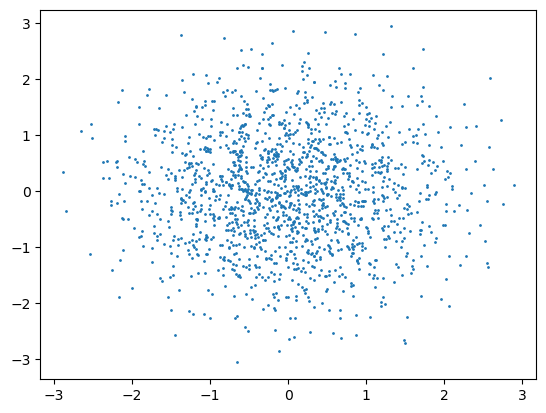

In [4]:
plt.scatter(gaussian_solver.particles[:,0], gaussian_solver.particles[:,1], s=1)
plt.show()

# Rosenbrock

##### This is a harder distribution, which we can learn more easily by employing an annealing strategy, for which we use the variable `T`

In [5]:
a = 1 / 20
b = 5

def rosenbrock_logdensity(x, T):
    """
    Log-density of the 2D Rosenbrock distribution.
    x : shape (2,) — as expected by MSVGD's logdensity argument
    returns : shape (1,)
    """
    x1, x2 = x
    return (-a*(1 - x1)**2 - b*((x2 - x1**2)**2)) / T

In [6]:
key = jr.PRNGKey(2)
x0 = jr.normal(key, shape=(200, 2))

for i, T in enumerate(jnp.arange(11, 1, -5)):
    rosenbrock_solver = MSVGD(lambda x: rosenbrock_logdensity(x, 1))
    x0 = rosenbrock_solver.solve(
            x0, 
            random_seed=i,
            mitosis_splits=max([2-i, 0]),
            atol=5e-3,
            optimizer_kwargs={'learning_rate':0.1})

Split 0 finished after 488 iterations | max grad = 0.00453
Split 1 finished after 847 iterations | max grad = 0.00500
Split 2 finished after 533 iterations | max grad = 0.00499
Split 0 finished after 1 iterations | max grad = 0.00498
Split 1 finished after 505 iterations | max grad = 0.00499


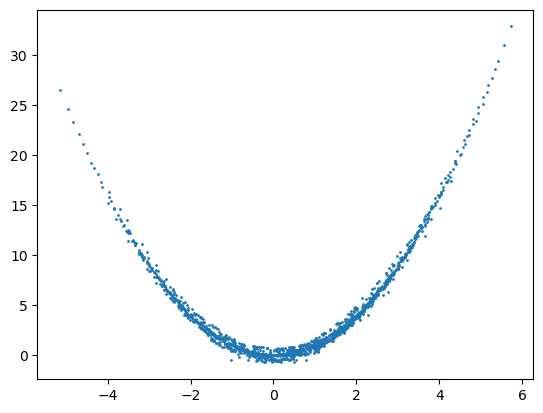

In [7]:
plt.scatter(rosenbrock_solver.particles[:,0], rosenbrock_solver.particles[:,1], s=1)
plt.show()

# Normal Inverse-Chisquare

##### The chisquare component of this distribution is strictly positive. One way to handle this is to set the log-density of negative values to -inf, but it is more stable to reparametrize it by its log.

In [8]:
mu0    = 0.0
kappa0 = 1.0
nu0    = 3.0
sigma0_sq = 1.0

def normal_inverse_chi2_logdensity_reparam(x):
    """
    Reparametrized log-density of the Normal Inverse-Chisquare distribution.
    x : shape (2,) — as expected by MSVGD's logdensity argument
        x[0] is mu, x[1] is psi = log(sigma^2)
    returns : shape (1,)
    Jacobian term log|d(sigma^2)/d(psi)| = psi is added for correct density.
    """
    mu, psi  = x
    var = jnp.exp(psi)

    return (
        -(nu0 + 3) / 2 * psi
        - (nu0 * sigma0_sq + kappa0 * (mu - mu0) ** 2) / (2 * var)
        + psi
    )

In [9]:
nix_solver = MSVGD(normal_inverse_chi2_logdensity_reparam)
x0 = jr.normal(jr.PRNGKey(3), shape=(200, 2))
_ = nix_solver.solve(x0, mitosis_splits=3, optimizer_kwargs={'learning_rate':0.1})

Split 0 finished after 44 iterations | max grad = 0.00993
Split 1 finished after 47 iterations | max grad = 0.00849
Split 2 finished after 38 iterations | max grad = 0.00925
Split 3 finished after 35 iterations | max grad = 0.00966


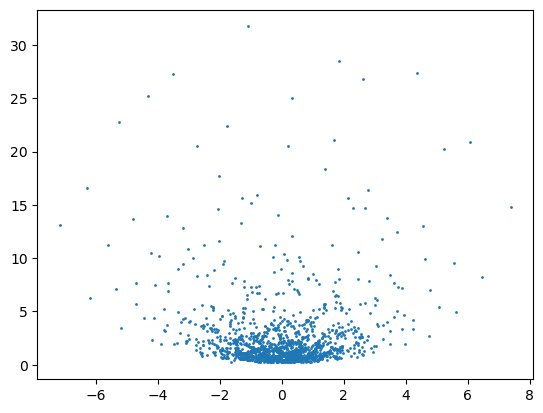

In [10]:
plt.scatter(nix_solver.particles[:,0], jnp.exp(nix_solver.particles[:,1]), s=1)
plt.show()

# Gaussian Ring Mixture

In [11]:
n_modes = 6
radius  = 3.0
sigma2  = 0.1

# Mode centers arranged evenly around a circle
angles  = jnp.linspace(0, 2 * jnp.pi, n_modes, endpoint=False)
centres = jnp.stack([radius * jnp.cos(angles),
                     radius * jnp.sin(angles)], axis=1) # (n_modes, 2)

def ring_mixture_logdensity(x, T):
    """
    Log-density of a ring mixture of bivariate Gaussian distributions.
    x : (2,) — as expected by MSVGD
    returns : (1,)
    """
    log_weights = jnp.zeros(n_modes) # uniform mixture
    sq_dists = jnp.sum((centres - x) ** 2, axis=1) # (n_modes,)
    log_kernels = -sq_dists / (2 * sigma2) # (n_modes,)
    return jnp.array([jax.nn.logsumexp(log_weights + log_kernels)]) / T

In [12]:
x0 = jr.normal(key, shape=(200, 2))

for i, T in enumerate(jnp.arange(21, 1, -4)):
    grm_solver = MSVGD(lambda x: ring_mixture_logdensity(x, T))
    x0 = grm_solver.solve(
            x0,
            random_seed=i,
            mitosis_splits=max([2-i, 0]),
            atol=5e-3,
            optimizer_kwargs={'learning_rate':0.1}
    )

Split 0 finished after 79 iterations | max grad = 0.00497
Split 1 finished after 38 iterations | max grad = 0.00485
Split 2 finished after 36 iterations | max grad = 0.00489
Split 0 finished after 9 iterations | max grad = 0.00499
Split 1 finished after 25 iterations | max grad = 0.00489
Split 0 finished after 12 iterations | max grad = 0.00485
Split 0 finished after 19 iterations | max grad = 0.00460
Split 0 finished after 41 iterations | max grad = 0.00492


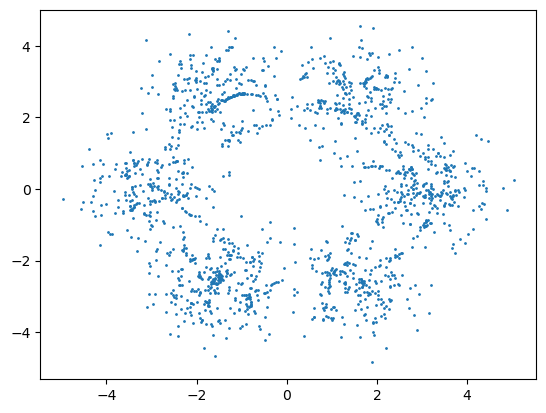

In [13]:
plt.scatter(grm_solver.particles[:,0], grm_solver.particles[:,1], s=1)
plt.show()

## Mode-finding

In [14]:
x0 = jr.normal(key, shape=(200, 2)) * 5

grm_solver_MAP = MSVGD(lambda x: ring_mixture_logdensity(x, T))
_ = grm_solver_MAP.solve(
    x0,
    is_MAP=True,
    mitosis_splits=0,
    atol=5e-3,
    optimizer_kwargs={'learning_rate':0.1}
)

Split 0 finished after 554 iterations | max grad = 0.00495


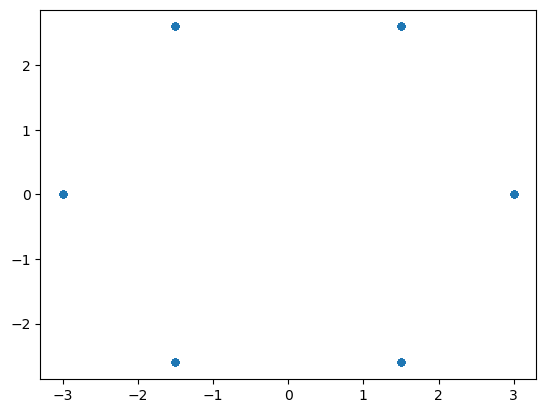

In [15]:
plt.scatter(grm_solver_MAP.particles[:,0], grm_solver_MAP.particles[:,1], s=20)
plt.show()

# Batched Gradient Descent - Bayesian Linear Regression

In [16]:
key = jr.PRNGKey(5)
N, D = 5000, 2         # 5000 observations, 2 features
sigma = 0.5            # observation noise std
alpha = 2.0            # prior std on weights

key, k1, k2, k3 = jr.split(key, 4)
X      = jr.normal(k1, (N, D))
w_true = jnp.array([1.5, -0.8])
y      = X @ w_true + sigma * jr.normal(k2, (N,))

data = jnp.concatenate([X, y[:, None]], axis=1)   # (N, D+1)

prior_prec  = jnp.eye(D) / alpha**2
data_prec   = X.T @ X / sigma**2
post_cov    = jnp.linalg.inv(data_prec + prior_prec)
post_mean   = post_cov @ (X.T @ y) / sigma**2

# Mini-batched log-density
def blr_logdensity(w, data_batch):
    # w          : (D,)
    # data_batch : (B, D+1)
    B  = data_batch.shape[0]
    Xb = data_batch[:, :D]
    yb = data_batch[:, D]

    log_lik   = -0.5 * jnp.sum((yb - Xb @ w) ** 2) / sigma**2
    log_prior = -0.5 * jnp.sum(w ** 2) / alpha**2
    return (N / B) * log_lik + log_prior

In [17]:
blr_solver = MSVGD(blr_logdensity, data=data)

x0 = jr.normal(k3, (100, D))

particles = blr_solver.solve(
    x0,
    mitosis_splits=3,
    batch_size=1000,
    optimizer_kwargs={"learning_rate": 1e-3},
    max_iter=5_000,
)

Split 0 finished after 5000 iterations | max grad = 215.27403
Split 1 finished after 5000 iterations | max grad = 48.31282
Split 2 finished after 5000 iterations | max grad = 30.22607
Split 3 finished after 5000 iterations | max grad = 46.34380


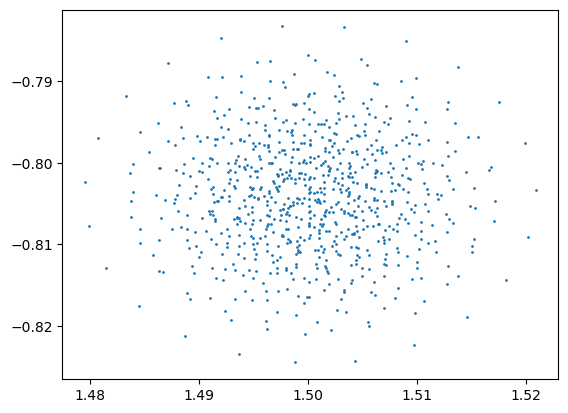

In [18]:
plt.scatter(blr_solver.particles[:,0], blr_solver.particles[:,1], s=1)
plt.show()

In [19]:
print("True parameters:", w_true)

print("\nTrue posterior mean:", post_mean)
print("True posterior std: ", jnp.sqrt(jnp.diag(post_cov)))

print("\nParticle mean: ", blr_solver.particles.mean(axis=0))
print("Particle std:  ", blr_solver.particles.std(axis=0))

True parameters: [ 1.5 -0.8]

True posterior mean: [ 1.5000672 -0.8038946]
True posterior std:  [0.00709523 0.00710555]

Particle mean:  [ 1.5001303  -0.80392945]
Particle std:   [0.00702987 0.00703986]
